//author: pdominguez                    
//date of creation/last modification: 23/1/2026               
//filesource: `tran_linearity_integration.raw`                  
//tb_schem: `tb_8xPI_linearity_integration.sch`               

# Presentación de resultados: linealidad del 8xPI top integrado

En esta notebook voy a presentar los resultados que se obtuvieron de la simulación del 8xPI "top" que integra los módulos 8xPI (módulo aislado), 2to4, código termométrico, un módulo de control que procesa ligeramente los bits de control y el ring oscillator.          

Esta versión del top no necesita clocks artificiales generados por estímulos, porque el oscilador interno ya genera los 4 clocks necesarios. No obstante, se necesita un tratamiento ligeramente especial del clock para mostrar los resultados correctamente (se debe determinar la frecuencia exacta de oscilación para superponer todas las fases en un gráfico).

Los resultados de simulación que se van a graficar en este archivo están en la salida de simulación `tran_linearity_integration.raw`.                   

In [336]:
### Seccion de imports

import matplotlib.pyplot as plt
import numpy as np

### Modificación de la función readRaw()

A continuación, se encuentra la nueva versión de la función `readRaw()`. El canbio con respecto a la versión anterior es que se agregó la capacidad de extraer la columna de valores de time (en el caso de transient analysis) o dc (en el caso de dc analysis).

In [337]:
def readRaw(rawfile: str, variables: list[str]) -> dict[str,list[float]]:
    """
    readRaw()
    =======
    Lee un archivo raw y devuelve las variables indicadas en un
    diccionario. Las llaves son el nombre de las variables en
    la simulacion, y los valores son listas que contienen el resultado
    de simulacion de su respectiva variable.

    @author: pdominguez. Contactense ante cualquier duda.

    Parameters
    ----------

    rawfile: str
             Archivo donde se almacenan las salidas de simulacion de ngspice. 
             El archivo debe estar configurado en filetype = ascii.
                    
    variables: list[str]
               Lista que contiene las llaves del diccionario de salida.
               Las llaves deben ser iguales a los nombres de las senales en la salida ascii.

    Returns
    -------

    dict[str,list[float]]
            Diccionario donde las llaves son strings iguales al nombre de la senal en simulacion, 
            y el valor es la lista de floats que contiene los valores simulados respectivos a esa 
            variable

    Examples of use
    ---------------

    Se supone que el archivo out_simul.raw es una salida de simulacion de ngspice configurada en 
    filetype = ascii, y tiene las siguientes senales con sus respectivos valores:
    
    >>> Variables:
	>>> 0	time	time
	>>> 1	v(vout)	voltage
	>>> 2	v(vout8i)	voltage
	>>> 3	v(vini)	voltage
    >>> Values:
    >>>  0 	0.000000000000000e+00
    >>> 	1.472053331554910e-08
    >>> 	1.472053337682925e-08
    >>> 	0.000000000000000e+00

    >>>  1	1.000000000000000e-13
    >>> 	1.493710519767057e-08
    >>> 	1.493710531305648e-08
    >>> 	4.800000000000000e-03

    >>>  2	2.000000000000000e-13
    >>> 	1.533147593858479e-08
    >>> 	1.533147614939112e-08
    >>> 	9.600000000000001e-03

    ...y demas puntos

    Se podria hacer:

    >>> variables = ['time','v(vout)','v(vout8i)','v(vini)']   
    >>> resultados = readRaw('out_simul.raw',variables)

    y luego:

    >>> time = resultados['time']
    >>> vout = resultados['v(vout)']

    y siguiendo con las otras senales.
    """
    out_dict = {}
    aux_dict = {}
    head = None

    with open(rawfile, 'r') as f:
        for line in f:
            linea = line.strip()
            #Flag para identificar la cabecera con las variables
            if(linea == 'Variables:'):
                head = True
            elif(linea == 'Values:'):
                head = False
            
            #Procesamiento de la cabecera y los datos
            if(head == True and linea != 'Variables:'):
                lin_split = linea.split()
                if lin_split[1] in variables:
                    aux_dict[int(lin_split[0])] = lin_split[1]
                    out_dict[lin_split[1]] = []

            elif(head == False and linea != 'Values:'):
                if(len(linea.split()) > 1):  #Nuevo instante de simulacion
                    offset = 0
                if offset in aux_dict:
                    if (offset != 0):
                        label = aux_dict[offset]
                        out_dict[label].append(float(linea))
                    else:
                        label = aux_dict[offset]
                        out_dict[label].append(float(linea.split()[1]))
                offset = offset + 1
    
    return out_dict

In [338]:
# Lectura de archivo

variables = ['time','v(vout)','v(vout8i)','v(vini)','v(vinib)',
             'v(x1.vi)','v(x1.vq)','v(x1.vib)','v(x1.vqb)',
             'v(x1.vst[1])','v(x1.vst[2])','v(x1.vst[3])',
             'v(x1.vst[4])','v(x1.vst[5])','v(x1.vst[6])','v(x1.vst[7])',
             'v(x1.vstq[1])','v(x1.vstq[2])','v(x1.vstq[3])','v(x1.vstq[4])',
             'v(x1.vstq[5])','v(x1.vstq[6])','v(x1.vstq[7])',
             'v(x1.vsq[0])','v(x1.vsq[1])','v(x1.vsq[2])']
resultados = readRaw('tran_linearity_ring_integration.raw',variables)

### Medición de la frecuencia de salida del 8xPI con salida en 8I

Como el top tiene un oscilador independiente interno, hay que medir la frecuencia exacta de ese oscilador.                    

Como se puede ver en la celda de código de arriba al principio, hay una variable que se llama `offs_time` y almacena la muestra en la que se encuentra el valor más cercano al tiempo `OFFS` en la simulación. Esto tiene que ver principalmente con el tiempo que dura el transitorio del ring donde todavía no estabilizó el clock de salida. Por simulaciones anteriores, se había visto que este tiempo podría ser de un aproximado de 10ns. En la simulación actual, por cuestiones de practicidad, se hizo transcurrir un tiempo de 28,492ns=3,5615ns*8 en la simulación (tiempo suficiente para que se estabilice el ring), y luego de eso se realiza el sweep de fase. Por cómo se están extrayendo los resultados, todos los datos que se verán corresponden a un tiempo posterior a 28,492ns.           

Ahora bien, porqué es importante medir precisamente la frecuencia del clock? Es más que nada por una cuestión visual y de prolijidad. En las gráficas donde se quiere observar el PI operando de manera visual, hace falta conocer la frecuencia casi exacta para generar ventanas de tiempo que tengan una duración múltiplo del periodo del clock, y luego superponer esos recortes periódicos uno encima del otro sobre un gráfico. Al tener recortes periódicos, el desfase de los flancos se puede ver de manera gráfica de manera correcta.                       

Luego de eso, conocer la frecuencia del oscilador no aporta mucho más, porque el resto de las mediciones se realizan en base a comparaciones de flancos independientes de la frecuencia. En la celda de abajo, voy a escribir una función que mida la frecuencia de la salida del 8xPI que se mantiene en 8I. Se entiende que, la frecuencia de ese 8xPI va a ser igual a la frecuencia del clock I del oscilador.

In [ ]:
def meas_period(sig_out: list[float],
                sig_time: list[float],
                threshold: float
                ) -> list[float]:
    
    """
    meas_period()
    ============
    Funcion para medir el periodo de una señal (presumiblemente cuadrada) de clock.

    @author: pdominguez - Contactense sin problemas en caso de tener dudas. La funcion esta 
    implementada con algunas cantidades "hardcodeadas". Son libres de copiar esta funcion en
    su codigo y modificar estas cantidades para ajustarlas a su simulacion.

    Parameters
    ---------

    sig_out: list[float]
               senal de salida de simulacion.

    sig_time: list[float]
                senal de tiempo de simulacion.
    """

    meas_period = []
    pos_pw = []
    neg_pw = []
    first_posedge = 0
    time_meas = []
    data_ring = {}

    pos_level = False
    posedge1 = None
    negedge1 = None
    for i in range(len(sig_time)):
        if(sig_out[i] >= threshold and not pos_level):
            # Captura el flanco
            posedge2 = sig_time[i]
            time_meas.append(sig_time[i])
            if (posedge1 is None):
                first_posedge = posedge2
            else: 
                meas_period.append(posedge2 - posedge1)
                neg_pw.append(posedge2 - negedge1)
            pos_level = True
            posedge1 = posedge2
        
        if(sig_out[i] <= threshold and pos_level):
            # Identifica el flanco negativo
            pos_level = False
            negedge1 = sig_time[i]
            pos_pw.append(negedge1 - posedge1)

    data_ring["first_posedge"] = first_posedge
    data_ring["meas_period"] = meas_period
    data_ring["pos_pw"] = pos_pw
    data_ring["neg_pw"] = neg_pw
    data_ring["time_meas"] = time_meas
    
    return data_ring


El periodo más corto fue de:7.074999999999817e-10
El periodo más largo de :7.170000000002042e-10
El periodo promedio :7.122554347826092e-10
La diferencia equivale a un error de fase de 4.801648163097478


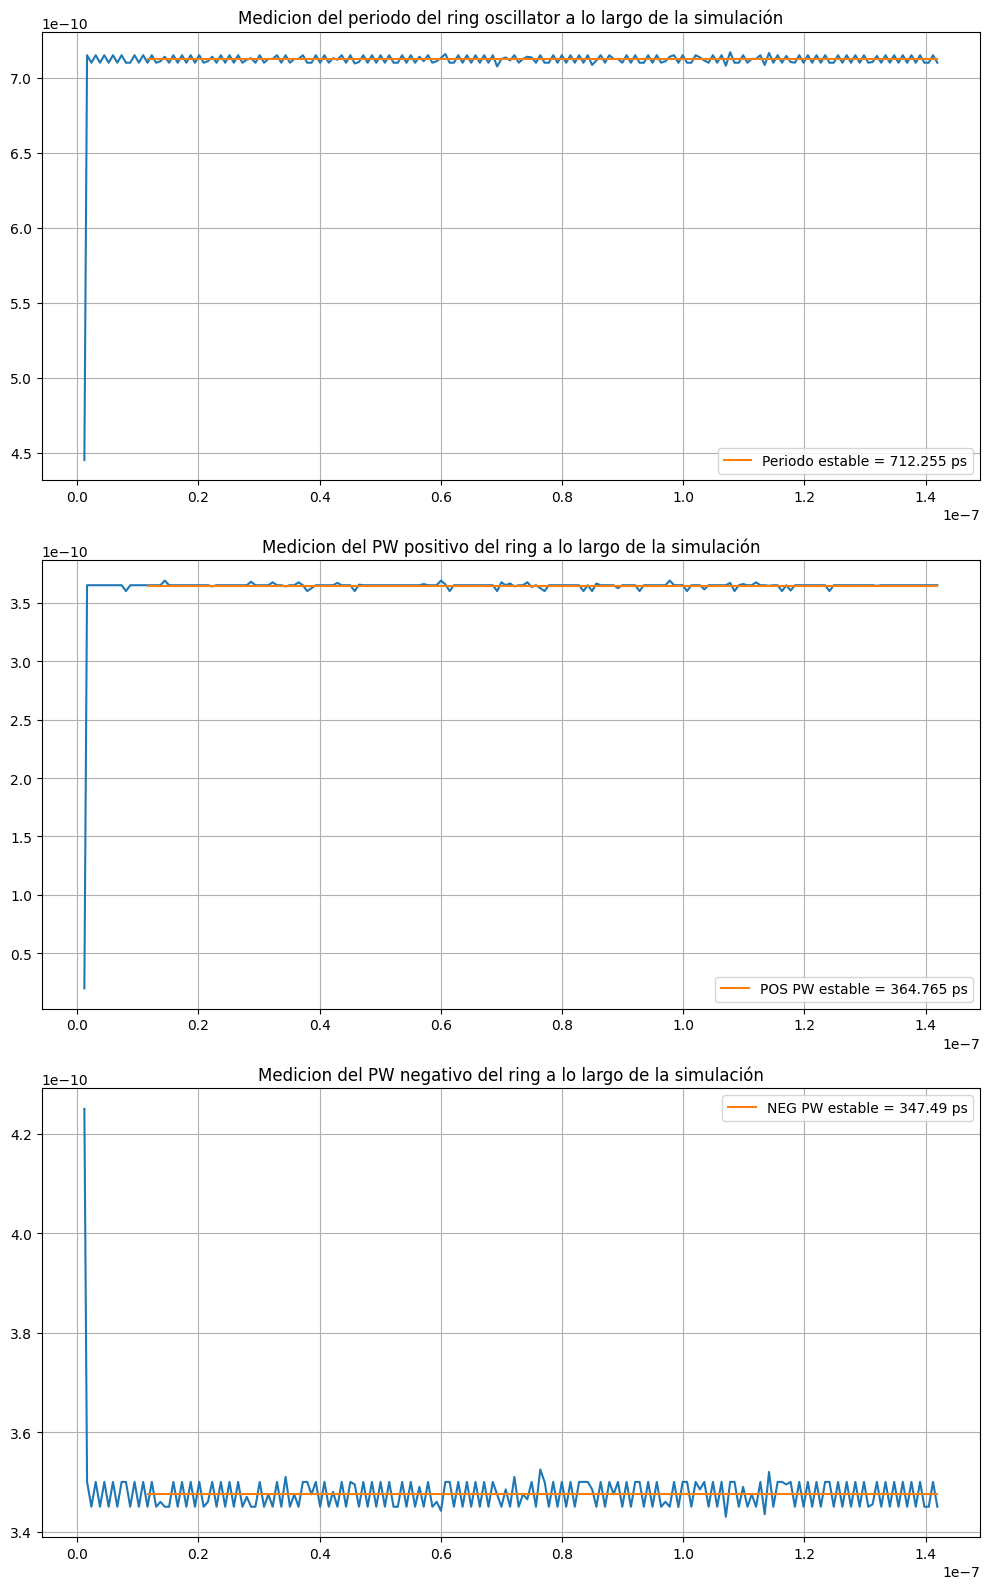

In [365]:
data_ring = meas_period(resultados["v(vout8i)"],resultados["time"],0.6)
transient_cycles = 15
stable_period = np.mean(data_ring["meas_period"][transient_cycles:])
min_stable_period = np.min(data_ring["meas_period"][transient_cycles:])
max_stable_period = np.max(data_ring["meas_period"][transient_cycles:])
stable_pos_pw = np.mean(data_ring["pos_pw"][transient_cycles:])
stable_neg_pw = np.mean(data_ring["neg_pw"][transient_cycles:])

fig_ring = plt.figure(figsize=[10,16])
period_ring_ax = fig_ring.add_subplot(3,1,1)
pos_pw_ring_ax = fig_ring.add_subplot(3,1,2)
neg_pw_ring_ax = fig_ring.add_subplot(3,1,3)


period_ring_ax.plot(data_ring["time_meas"][:-1],data_ring["meas_period"])
period_ring_ax.plot(data_ring["time_meas"][transient_cycles:-1],
                    [stable_period]*len(data_ring["time_meas"][transient_cycles:-1]),
                    label=f"Periodo estable = {np.round(stable_period*1e12,decimals=3)} ps")
period_ring_ax.legend()
period_ring_ax.grid()
period_ring_ax.set_title("Medicion del periodo del ring oscillator a lo largo de la simulación")                    

pos_pw_ring_ax.plot(data_ring["time_meas"][:-1],data_ring["pos_pw"])
pos_pw_ring_ax.plot(data_ring["time_meas"][transient_cycles:-1],
                    [stable_pos_pw]*len(data_ring["time_meas"][transient_cycles:-1]),
                    label=f"POS PW estable = {np.round(stable_pos_pw*1e12,decimals=3)} ps")
pos_pw_ring_ax.legend()
pos_pw_ring_ax.grid()
pos_pw_ring_ax.set_title("Medicion del PW positivo del ring a lo largo de la simulación")                    

neg_pw_ring_ax.plot(data_ring["time_meas"][:-1],data_ring["neg_pw"])
neg_pw_ring_ax.plot(data_ring["time_meas"][transient_cycles:-1],
                    [stable_neg_pw]*len(data_ring["time_meas"][transient_cycles:-1]),
                    label=f"NEG PW estable = {np.round(stable_neg_pw*1e12,decimals=3)} ps")
neg_pw_ring_ax.legend()
neg_pw_ring_ax.grid()
neg_pw_ring_ax.set_title("Medicion del PW negativo del ring a lo largo de la simulación")

fig_ring.tight_layout()
print(f"El periodo más corto fue de:{min_stable_period}")
print(f"El periodo más largo de :{max_stable_period}")
print(f"El periodo promedio :{stable_period}")
print(f"La diferencia equivale a un error de fase de {(max_stable_period-min_stable_period)*360/stable_period}")

In [339]:
### Duración de cada cuadrante
LEN_Q = 3.5615e-9*8
#LEN_Q = 20e-9
### Offset de captura de resultados
OFFS = 3.5615e-9*8
#OFFS = 0
offs_time = np.abs(np.array(resultados['time'], dtype=float) - OFFS).argmin()

# Primer cuadrante
len_timeQ1 = np.abs(np.array(resultados['time'], dtype=float) - LEN_Q - OFFS).argmin()
vout_Q1 = resultados['v(vout)'][offs_time:len_timeQ1]
v8i_Q1 = resultados['v(vout8i)'][offs_time:len_timeQ1]
vini_Q1 = resultados['v(vini)'][offs_time:len_timeQ1]
vinib_Q1 = resultados['v(vinib)'][offs_time:len_timeQ1]
v2to4i_Q1 = resultados['v(x1.vi)'][offs_time:len_timeQ1]
v2to4q_Q1 = resultados['v(x1.vq)'][offs_time:len_timeQ1]
v2to4ib_Q1 = resultados['v(x1.vib)'][offs_time:len_timeQ1]
v2to4qb_Q1 = resultados['v(x1.vqb)'][offs_time:len_timeQ1]
time_Q1 = resultados['time'][offs_time:len_timeQ1]

# Segundo cuadrante
len_timeQ2 = np.abs(np.array(resultados['time'], dtype=float) - 2*LEN_Q - OFFS).argmin()
vout_Q2 = resultados['v(vout)'][len_timeQ1:len_timeQ2]
v8i_Q2 = resultados['v(vout8i)'][len_timeQ1:len_timeQ2]
vini_Q2 = resultados['v(vini)'][len_timeQ1:len_timeQ2]
vinib_Q2 = resultados['v(vinib)'][len_timeQ1:len_timeQ2]
v2to4i_Q2 = resultados['v(x1.vi)'][len_timeQ1:len_timeQ2]
v2to4q_Q2 = resultados['v(x1.vq)'][len_timeQ1:len_timeQ2]
v2to4ib_Q2 = resultados['v(x1.vib)'][len_timeQ1:len_timeQ2]
v2to4qb_Q2 = resultados['v(x1.vqb)'][len_timeQ1:len_timeQ2]
time_Q2 = resultados['time'][len_timeQ1:len_timeQ2]

# Tercer cuadrante
len_timeQ3 = np.abs(np.array(resultados['time'], dtype=float) - 3*LEN_Q - OFFS).argmin()
vout_Q3 = resultados['v(vout)'][len_timeQ2:len_timeQ3]
v8i_Q3 = resultados['v(vout8i)'][len_timeQ2:len_timeQ3]
vini_Q3 = resultados['v(vini)'][len_timeQ2:len_timeQ3]
vinib_Q3 = resultados['v(vinib)'][len_timeQ2:len_timeQ3]
v2to4i_Q3 = resultados['v(x1.vi)'][len_timeQ2:len_timeQ3]
v2to4q_Q3 = resultados['v(x1.vq)'][len_timeQ2:len_timeQ3]
v2to4ib_Q3 = resultados['v(x1.vib)'][len_timeQ2:len_timeQ3]
v2to4qb_Q3 = resultados['v(x1.vqb)'][len_timeQ2:len_timeQ3]
time_Q3 = resultados['time'][len_timeQ2:len_timeQ3]

# Cuarto cuadrante
len_timeQ4 = np.abs(np.array(resultados['time'], dtype=float) - 4*LEN_Q - OFFS).argmin()
vout_Q4 = resultados['v(vout)'][len_timeQ3:len_timeQ4]
v8i_Q4 = resultados['v(vout8i)'][len_timeQ3:len_timeQ4]
vini_Q4 = resultados['v(vini)'][len_timeQ3:len_timeQ4]
vinib_Q4 = resultados['v(vinib)'][len_timeQ3:len_timeQ4]
v2to4i_Q4 = resultados['v(x1.vi)'][len_timeQ3:len_timeQ4]
v2to4q_Q4 = resultados['v(x1.vq)'][len_timeQ3:len_timeQ4]
v2to4ib_Q4 = resultados['v(x1.vib)'][len_timeQ3:len_timeQ4]
v2to4qb_Q4 = resultados['v(x1.vqb)'][len_timeQ3:len_timeQ4]
time_Q4 = resultados['time'][len_timeQ3:len_timeQ4]

# Bits de control
# Termo_in
t_in1 = resultados['v(x1.vst[1])']
t_in2 = resultados['v(x1.vst[2])']
t_in3 = resultados['v(x1.vst[3])']
t_in4 = resultados['v(x1.vst[4])']
t_in5 = resultados['v(x1.vst[5])']
t_in6 = resultados['v(x1.vst[6])']
t_in7 = resultados['v(x1.vst[7])']
# Termo_out
t_out1 = resultados['v(x1.vstq[1])']
t_out2 = resultados['v(x1.vstq[2])']
t_out3 = resultados['v(x1.vstq[3])']
t_out4 = resultados['v(x1.vstq[4])']
t_out5 = resultados['v(x1.vstq[5])']
t_out6 = resultados['v(x1.vstq[6])']
t_out7 = resultados['v(x1.vstq[7])']
# Selectores de cuadrante
qsel_MSB = resultados['v(x1.vsq[1])']
qsel_LSB = resultados['v(x1.vsq[0])']
# XOR bit
xor_bit = resultados['v(x1.vsq[2])']

# Limites de los cuadrantes
print(resultados['time'][offs_time])
print(time_Q1[0])
print(time_Q1[-1])
print(time_Q2[0])
print(time_Q2[-1])
print(time_Q3[0])
print(time_Q3[-1])
print(time_Q4[0])
print(time_Q4[-1])

2.849199999999999e-08
2.849199999999999e-08
5.698249999999997e-08
5.6984e-08
8.547350000000001e-08
8.547599999999999e-08
1.139675000000002e-07
1.13968e-07
1.424575e-07


### Función para graficar cada cuadrante

Cada cuadrante está dividido en 8 segmentos que corresponden a cada una de las 8 fases que "entran" dentro del cuadrante. A continuación, voy a escribir una función que, dandole el vector de datos en el tiempo de un cuadrante, grafique las 8 fases superpuestas en una misma ventana de tiempo.          

Para la simulación que yo planteé, cada cuadrante dura 20ns, por ende, cada una de las 8 fases del cuadrante dura 2.5ns. Pasado a ciclos de reloj, estos serían 5 ciclos de reloj para cada valor de fase.     

No obstante, para poder apreciar el desfase entre las señales correctamente, se debería graficar un solo flanco ascendente en la ventana de tiempo.

In [342]:
def graph_QUADRv3(quadr_out: list[float],
                  quadr_time: list[float],
                  quadr: int,
                  stable_period: float,
                  quadr_label: list[str],
                  subplot: plt.Axes) -> None:
    """
    graph_QUADRv3()
    ============
    Funcion para graficar todas las fases de un solo cuadrante superpuestas, hablando en
    el contexto de un PI de 4 cuadrantes.

    Esta segunda version de la funcion recorre todos los cuadrantes en sentido antihorario
    porque el sweep de fase ya estaria modificado para ser lineal con el aumento del control.

    @author: pdominguez - Contactense sin problemas en caso de tener dudas. La funcion esta 
    implementada con algunas cantidades "hardcodeadas". Son libres de copiar esta funcion en
    su codigo y modificar estas cantidades para ajustarlas a su simulacion.

    Parameters
    ---------

    quadr_out: list[float]
               senal de salida de simulacion.

    quadr_time: list[float]
                senal de tiempo de simulacion,

    quadr: integer
           numero de cuadrante al que pertenece la senal,

    quadr_label: list[str]
                 limites de fase que delimitan el cuadrante. 

    subplot: plt.Axes
             subplot (objeto axes de matplotlib) donde se grafica. 
    """
    for i in np.arange(0,8):
        len_time_seg1 = np.abs(quadr_time - (i+1)*stable_period*5 - (quadr)*stable_period*40).argmin()
        len_time_seg0 = np.abs(quadr_time - (i)*stable_period*5 - (quadr)*stable_period*40).argmin()
        subplot.plot(quadr_time[len_time_seg0:len_time_seg1]-i*stable_period*5 - (quadr-1)*stable_period*40,
                 quadr_out[len_time_seg0:len_time_seg1],
                 label = f'{i}{quadr_label[0]}+{8-i}{quadr_label[1]}')
        #print(f'len_time_seg0:{len_time_seg0}')
        #print(f'len_time_seg1:{len_time_seg1}')
        print(f'quadr_time[len_time_seg0]:{quadr_time[len_time_seg0]}')
        print(f'quadr_time[len_time_seg1]:{quadr_time[len_time_seg1]}')
        
        subplot.grid(True)
        subplot.legend()

7.122554347826092e-10
quadr_time[len_time_seg0]:2.849199999999999e-08
quadr_time[len_time_seg1]:3.205217999999997e-08
quadr_time[len_time_seg0]:3.205217999999997e-08
quadr_time[len_time_seg1]:3.56125e-08
quadr_time[len_time_seg0]:3.56125e-08
quadr_time[len_time_seg1]:3.9174e-08
quadr_time[len_time_seg0]:3.9174e-08
quadr_time[len_time_seg1]:4.273549999999999e-08
quadr_time[len_time_seg0]:4.273549999999999e-08
quadr_time[len_time_seg1]:4.629508000000007e-08
quadr_time[len_time_seg0]:4.629508000000007e-08
quadr_time[len_time_seg1]:4.98585e-08
quadr_time[len_time_seg0]:4.98585e-08
quadr_time[len_time_seg1]:5.341999999999998e-08
quadr_time[len_time_seg0]:5.341999999999998e-08
quadr_time[len_time_seg1]:5.698249999999997e-08
quadr_time[len_time_seg0]:5.6984e-08
quadr_time[len_time_seg1]:6.054040000000002e-08
quadr_time[len_time_seg0]:6.054040000000002e-08
quadr_time[len_time_seg1]:6.410450000000002e-08
quadr_time[len_time_seg0]:6.410450000000002e-08
quadr_time[len_time_seg1]:6.766600000000002

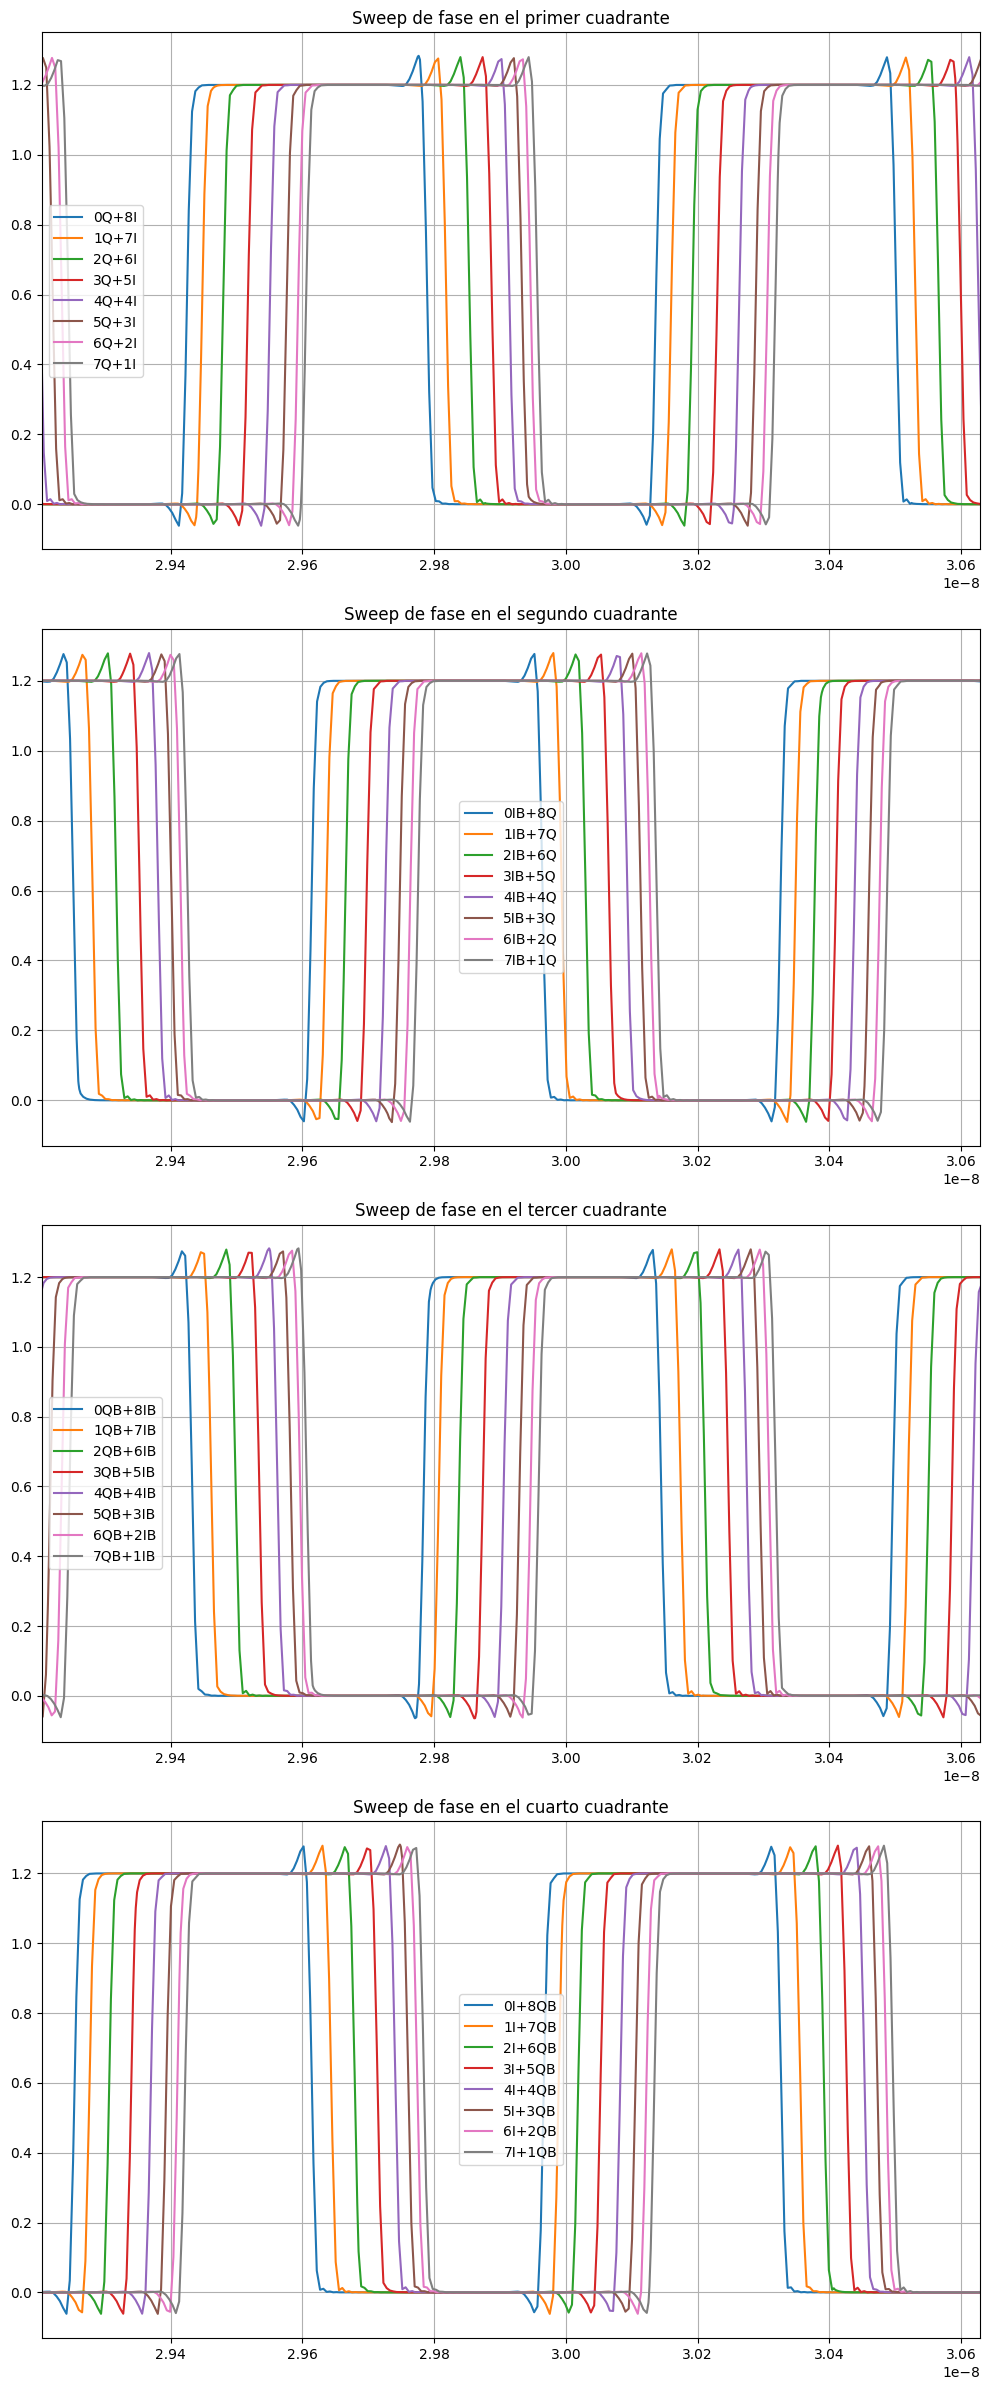

In [343]:
# Generación de ventana de gráficos
results = plt.figure(figsize=[10,24])
quadrant1 = results.add_subplot(4,1,1)
quadrant2 = results.add_subplot(4,1,2)
quadrant3 = results.add_subplot(4,1,3)
quadrant4 = results.add_subplot(4,1,4)

print(stable_period)
# Primer cuadrante
graph_QUADRv3(vout_Q1,time_Q1,1,stable_period,['Q','I'],quadrant1)
quadrant1.set_xlim(OFFS+stable_period, OFFS+stable_period*3)
quadrant1.set_title('Sweep de fase en el primer cuadrante')

# Segundo cuadrante
graph_QUADRv3(vout_Q2,time_Q2,2,stable_period,['IB','Q'],quadrant2)
quadrant2.set_xlim(OFFS+stable_period, OFFS+stable_period*3)
quadrant2.set_title('Sweep de fase en el segundo cuadrante')

# Tercer cuadrante
graph_QUADRv3(vout_Q3,time_Q3,3,stable_period,['QB','IB'],quadrant3)
quadrant3.set_xlim(OFFS+stable_period, OFFS+stable_period*3)
quadrant3.set_title('Sweep de fase en el tercer cuadrante')

# Cuarto cuadrante
graph_QUADRv3(vout_Q4,time_Q4,4,stable_period,['I','QB'],quadrant4)
quadrant4.set_xlim(OFFS+stable_period, OFFS+stable_period*3)
quadrant4.set_title('Sweep de fase en el cuarto cuadrante')

results.tight_layout()

## Validación del método (o la función) con la que se grafican los resultados

Para tener una idea de si la función está bien implementada y no introduce desviaciones de fase en el acto de superponer las señales, se utilizó esta misma función para graficar un estímulo idealmente periódico en la simulación.                      
Este estímulo es el clock I que se genera con un estímulo PULSE de ngspice. Esta señal en la simulación es la que tiene el label de vinI.

quadr_time[len_time_seg0]:2.849199999999999e-08
quadr_time[len_time_seg1]:3.205217999999997e-08
quadr_time[len_time_seg0]:3.205217999999997e-08
quadr_time[len_time_seg1]:3.56125e-08
quadr_time[len_time_seg0]:3.56125e-08
quadr_time[len_time_seg1]:3.9174e-08
quadr_time[len_time_seg0]:3.9174e-08
quadr_time[len_time_seg1]:4.273549999999999e-08
quadr_time[len_time_seg0]:4.273549999999999e-08
quadr_time[len_time_seg1]:4.629508000000007e-08
quadr_time[len_time_seg0]:4.629508000000007e-08
quadr_time[len_time_seg1]:4.98585e-08
quadr_time[len_time_seg0]:4.98585e-08
quadr_time[len_time_seg1]:5.341999999999998e-08
quadr_time[len_time_seg0]:5.341999999999998e-08
quadr_time[len_time_seg1]:5.698249999999997e-08
quadr_time[len_time_seg0]:2.849199999999999e-08
quadr_time[len_time_seg1]:3.205217999999997e-08
quadr_time[len_time_seg0]:3.205217999999997e-08
quadr_time[len_time_seg1]:3.56125e-08
quadr_time[len_time_seg0]:3.56125e-08
quadr_time[len_time_seg1]:3.9174e-08
quadr_time[len_time_seg0]:3.9174e-08


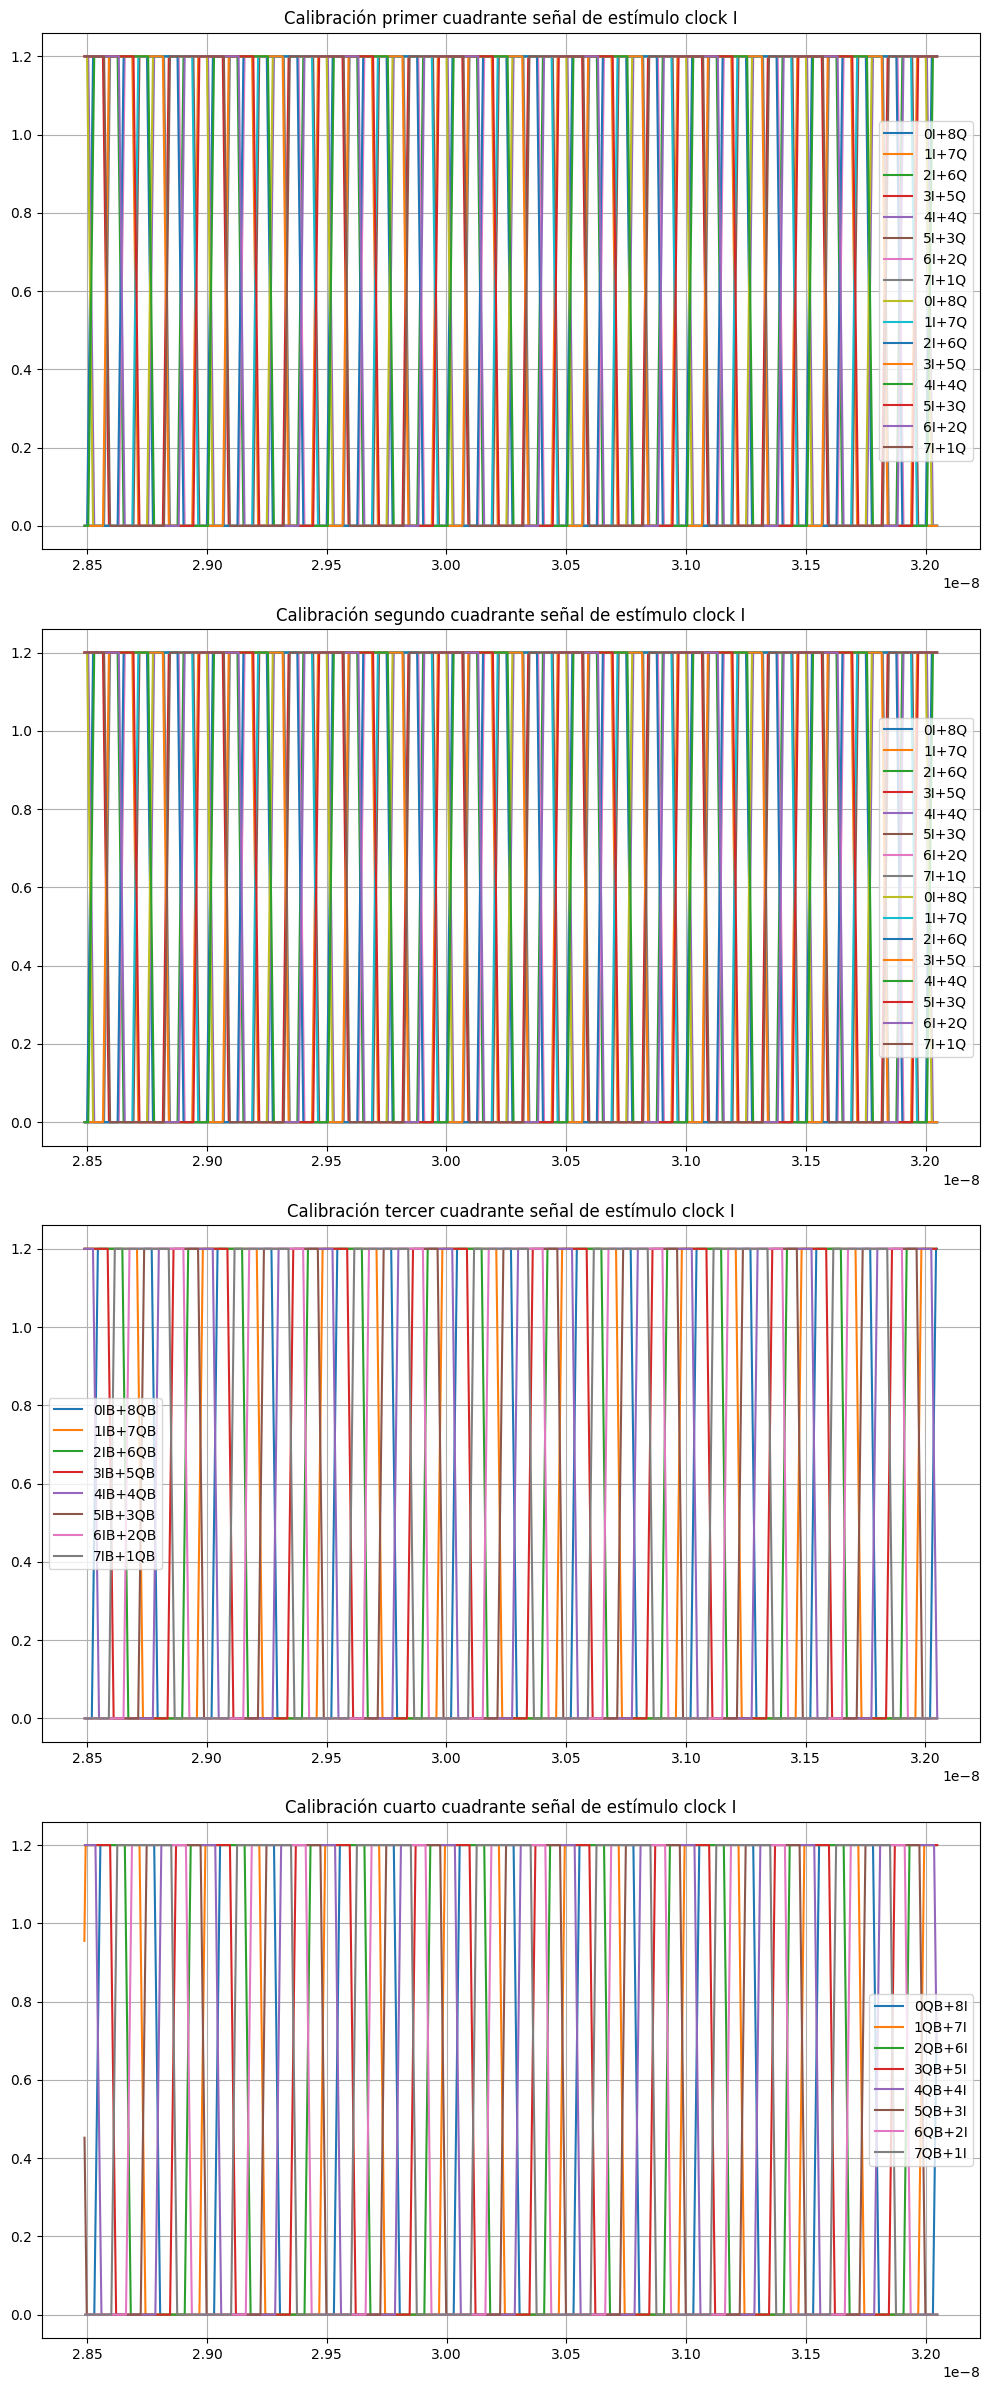

In [344]:
# Generación de ventana de gráficos
results8i = plt.figure(figsize=[10,24])
quadrant18i = results8i.add_subplot(4,1,1)
quadrant28i = results8i.add_subplot(4,1,2)
quadrant38i = results8i.add_subplot(4,1,3)
quadrant48i = results8i.add_subplot(4,1,4)

# Primer cuadrante
graph_QUADRv3(vini_Q1,time_Q1,1,stable_period,['I','Q'],quadrant18i)
graph_QUADRv3(vinib_Q1,time_Q1,1,stable_period,['I','Q'],quadrant18i)
#quadrant18i.set_xlim(1e-9, 2e-9)
quadrant18i.set_title('Calibración primer cuadrante señal de estímulo clock I')

# Segundo cuadrante
graph_QUADRv3(vini_Q1,time_Q1,1,stable_period,['I','Q'],quadrant28i)
graph_QUADRv3(vinib_Q1,time_Q1,1,stable_period,['I','Q'],quadrant28i)
#quadrant28i.set_xlim(1e-9+LEN_Q, 2e-9+LEN_Q)
quadrant28i.set_title('Calibración segundo cuadrante señal de estímulo clock I')

# Tercer cuadrante
graph_QUADRv3(vini_Q3,time_Q3,3,stable_period,['IB','QB'],quadrant38i)
#quadrant38i.set_xlim(1e-9+2*LEN_Q, 2e-9+2*LEN_Q)
quadrant38i.set_title('Calibración tercer cuadrante señal de estímulo clock I')

# Cuarto cuadrante
graph_QUADRv3(vini_Q4,time_Q4,4,stable_period,['QB','I'],quadrant48i)
#quadrant48i.set_xlim(1e-9+3*LEN_Q, 2e-9+3*LEN_Q)
quadrant48i.set_title('Calibración cuarto cuadrante señal de estímulo clock I')

results8i.tight_layout()

### Ploteo de la fase 8I en la salida del 8xPI

En la simulación, se incluyó una instancia del 8xPI a la que se le variaron las entradas de control para obtener las variaciones de fase en la salida ya graficadas más arriba. No obstante, también se incluyó una instancia a la que no se le modificó las entradas de control, manteniendolas fijas para que todo el tiempo genere la fase 8I.                   

Se hizo la misma verificación que con la señal vinI graficada justo arriba, pero ahora con la salida del 8xPI que debería mantener la fase constante a lo largo de toda la simulación. El resultado es simular, más allá de alguna distorsión en los transitorios producto de las capacitancias del diseño, las 8 salidas se grafican en fase dejando una sola traza.


quadr_time[len_time_seg0]:2.849199999999999e-08
quadr_time[len_time_seg1]:3.205217999999997e-08
quadr_time[len_time_seg0]:3.205217999999997e-08
quadr_time[len_time_seg1]:3.56125e-08
quadr_time[len_time_seg0]:3.56125e-08
quadr_time[len_time_seg1]:3.9174e-08
quadr_time[len_time_seg0]:3.9174e-08
quadr_time[len_time_seg1]:4.273549999999999e-08
quadr_time[len_time_seg0]:4.273549999999999e-08
quadr_time[len_time_seg1]:4.629508000000007e-08
quadr_time[len_time_seg0]:4.629508000000007e-08
quadr_time[len_time_seg1]:4.98585e-08
quadr_time[len_time_seg0]:4.98585e-08
quadr_time[len_time_seg1]:5.341999999999998e-08
quadr_time[len_time_seg0]:5.341999999999998e-08
quadr_time[len_time_seg1]:5.698249999999997e-08
quadr_time[len_time_seg0]:5.6984e-08
quadr_time[len_time_seg1]:6.054040000000002e-08
quadr_time[len_time_seg0]:6.054040000000002e-08
quadr_time[len_time_seg1]:6.410450000000002e-08
quadr_time[len_time_seg0]:6.410450000000002e-08
quadr_time[len_time_seg1]:6.766600000000002e-08
quadr_time[len_ti

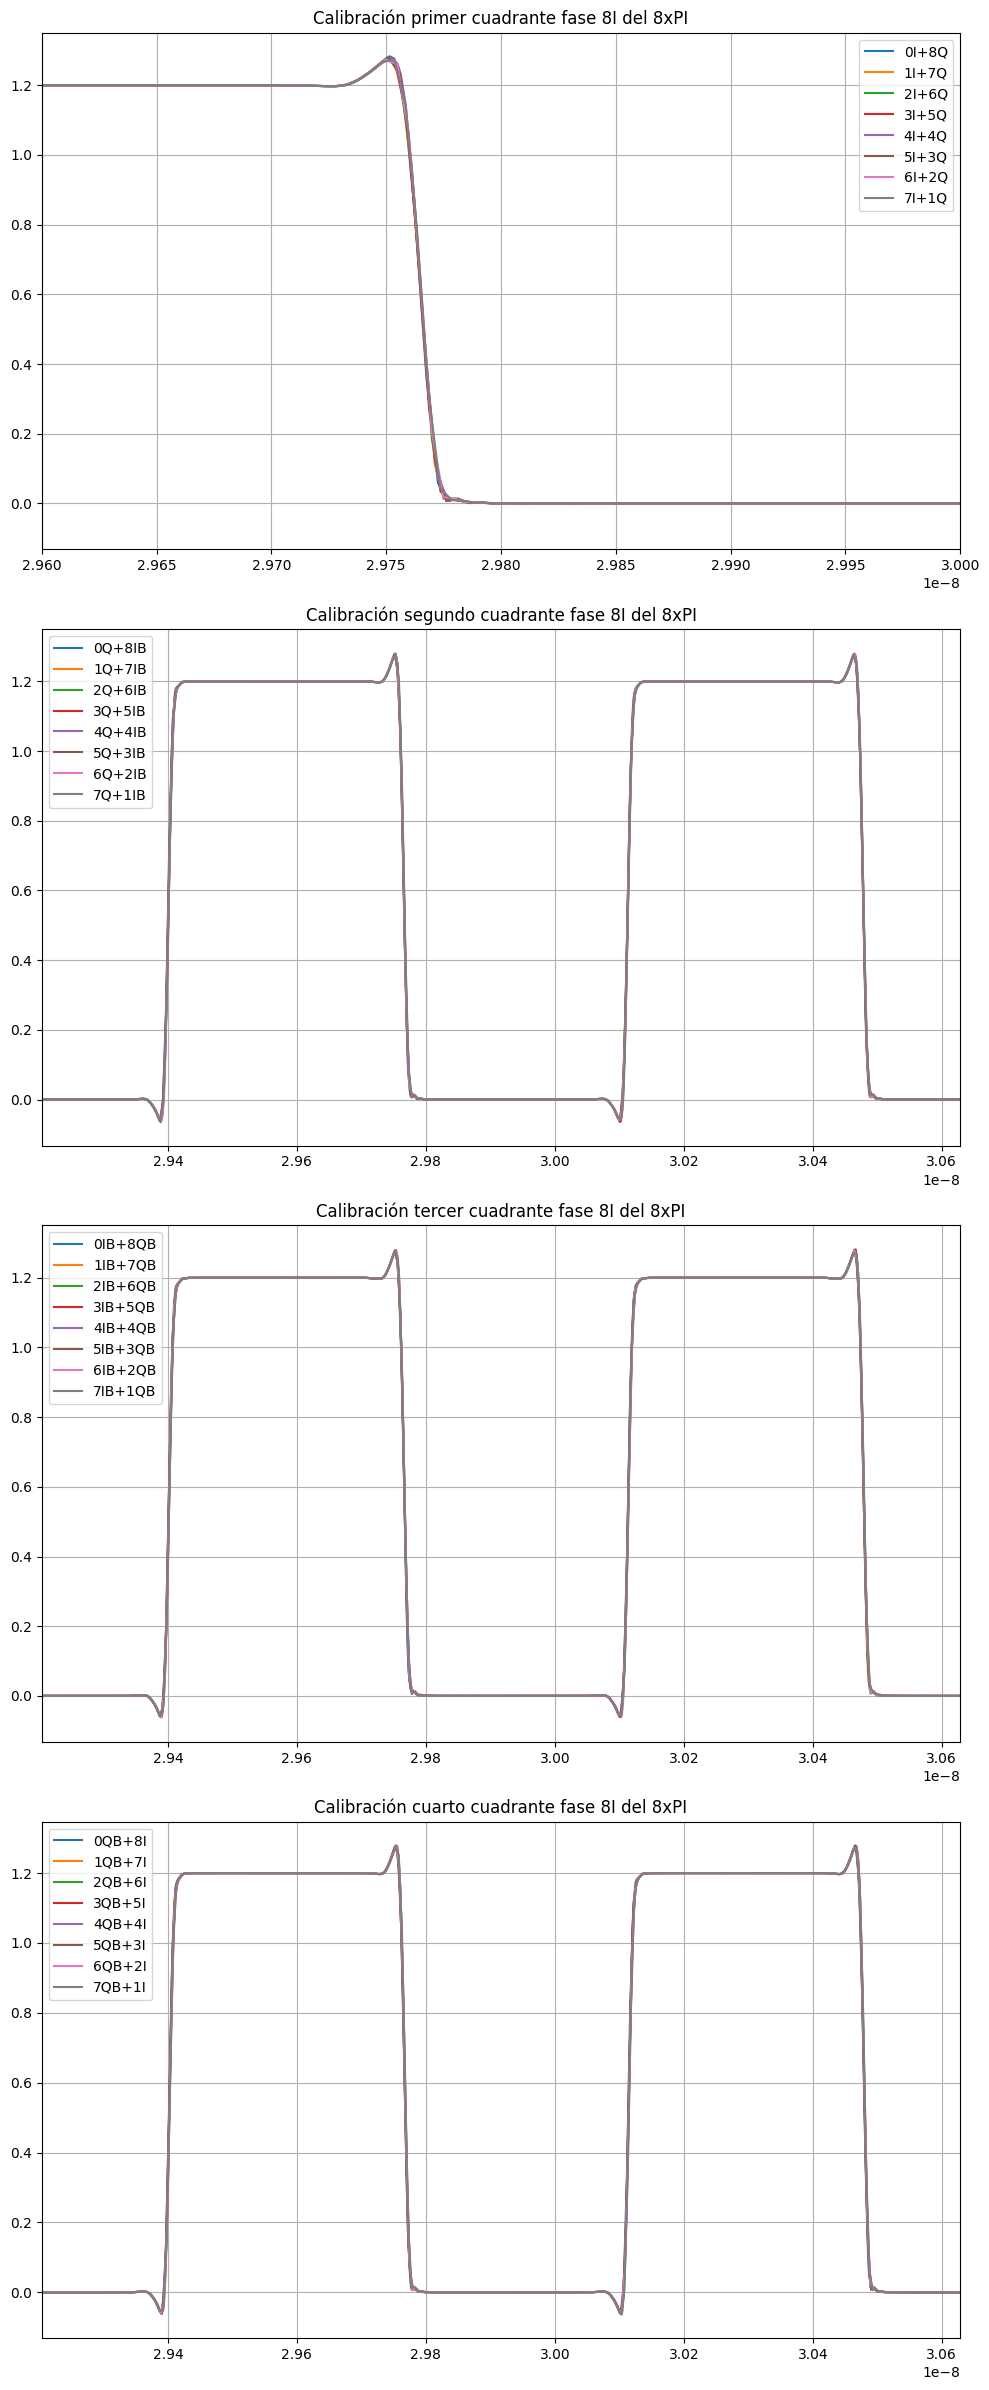

In [368]:
# Generación de ventana de gráficos
results8i = plt.figure(figsize=[10,24])
quadrant18i = results8i.add_subplot(4,1,1)
quadrant28i = results8i.add_subplot(4,1,2)
quadrant38i = results8i.add_subplot(4,1,3)
quadrant48i = results8i.add_subplot(4,1,4)

# Primer cuadrante
graph_QUADRv3(v8i_Q1,time_Q1,1,stable_period,['I','Q'],quadrant18i)
#quadrant18i.set_xlim(OFFS+stable_period, OFFS+stable_period*3)
quadrant18i.set_xlim(2.96e-8, 3.0e-8)
quadrant18i.set_title('Calibración primer cuadrante fase 8I del 8xPI')

# Segundo cuadrante
graph_QUADRv3(v8i_Q2,time_Q2,2,stable_period,['Q','IB'],quadrant28i)
quadrant28i.set_xlim(OFFS+stable_period, OFFS+stable_period*3)
quadrant28i.set_title('Calibración segundo cuadrante fase 8I del 8xPI')

# Tercer cuadrante
graph_QUADRv3(v8i_Q3,time_Q3,3,stable_period,['IB','QB'],quadrant38i)
quadrant38i.set_xlim(OFFS+stable_period, OFFS+stable_period*3)
#quadrant38i.set_xlim(4.14e-8, 4.15e-8)
quadrant38i.set_title('Calibración tercer cuadrante fase 8I del 8xPI')

# Cuarto cuadrante
graph_QUADRv3(v8i_Q4,time_Q4,4,stable_period,['QB','I'],quadrant48i)
quadrant48i.set_xlim(OFFS+stable_period, OFFS+stable_period*3)
quadrant48i.set_title('Calibración cuarto cuadrante fase 8I del 8xPI')

results8i.tight_layout()

### CLocks del 2to4

En este apartado voy a graficar las 4 salidas del 2to4, para los 4 cuadrantes. En total va a haber 4 subplots, uno para cada cuadrante. A su vez, cada subplot va a tener las 4 salidas del 2to4.             

Voy a crear una nueva función basada en `graph_QUADR()` para que tenga más sentido utilizarla para graficar los clocks de referencia. La función `graph_QUADR()` está diseñada para graficar un solo clock y ver cómo va variando la fase a lo largo de un cuadrante. Yo no quiero ver eso ahora con los clocks, quiero graficarlos "uno encima de otro" para ver cómo se comportan a lo largo de toda la simulación.

In [346]:
def clks_QUADRv2(quadr_out: list[float],
                quadr_time: list[float],
                quadr: int,
                stable_period: float,
                clk_label: str,
                color: str,
                subplot: plt.Axes) -> None:
    """
    graph_QUADR()
    ============
    Funcion para graficar todas las fases de un solo cuadrante superpuestas, hablando en
    el contexto de un PI de 4 cuadrantes.

    Para los cuadrantes 1 y 3, la simulacion deberia recorrer las fases en sentido
    antihorario. Para los cuadrantes 2 y 4, en canbio, la simulacion debe hacer el sweep
    de fase en sentido horario. 
    
    Esto es asi por la misma naturaleza del hardware que se diseno y como se ingresan los
    estimulos. El codigo termometrico hace un sweep periodico con periodo de un cuadrante. 

    @author: pdominguez - Contactense sin problemas en caso de tener dudas. La funcion esta 
    implementada con algunas cantidades "hardcodeadas". Son libres de copiar esta funcion en
    su codigo y modificar estas cantidades para ajustarlas a su simulacion.

    Parameters
    ---------

    quadr_out: list[float]
               senal de salida de simulacion.

    quadr_time: list[float]
                senal de tiempo de simulacion,

    quadr: integer
           numero de cuadrante al que pertenece la senal,

    quadr_label: list[str]
                 limites de fase que delimitan el cuadrante. 

    subplot: plt.Axes
             subplot (objeto axes de matplotlib) donde se grafica. 
    """
    for i in np.arange(0,8):        
        len_time_seg1 = np.abs(quadr_time - (i+1)*stable_period*5 - (quadr)*stable_period*40).argmin()
        len_time_seg0 = np.abs(quadr_time - (i)*stable_period*5 - (quadr)*stable_period*40).argmin()
        if (i == 0):
            subplot.plot(quadr_time[len_time_seg0:len_time_seg1]-i*stable_period*5 - (quadr-1)*stable_period*40,
                 quadr_out[len_time_seg0:len_time_seg1],
                 f'{color}',
                 label = f'Fase {clk_label}')
        else:
            subplot.plot(quadr_time[len_time_seg0:len_time_seg1]-i*stable_period*5 - (quadr-1)*stable_period*40,
                 quadr_out[len_time_seg0:len_time_seg1],
                 f'{color}')
        
        subplot.grid(True)
        subplot.legend()

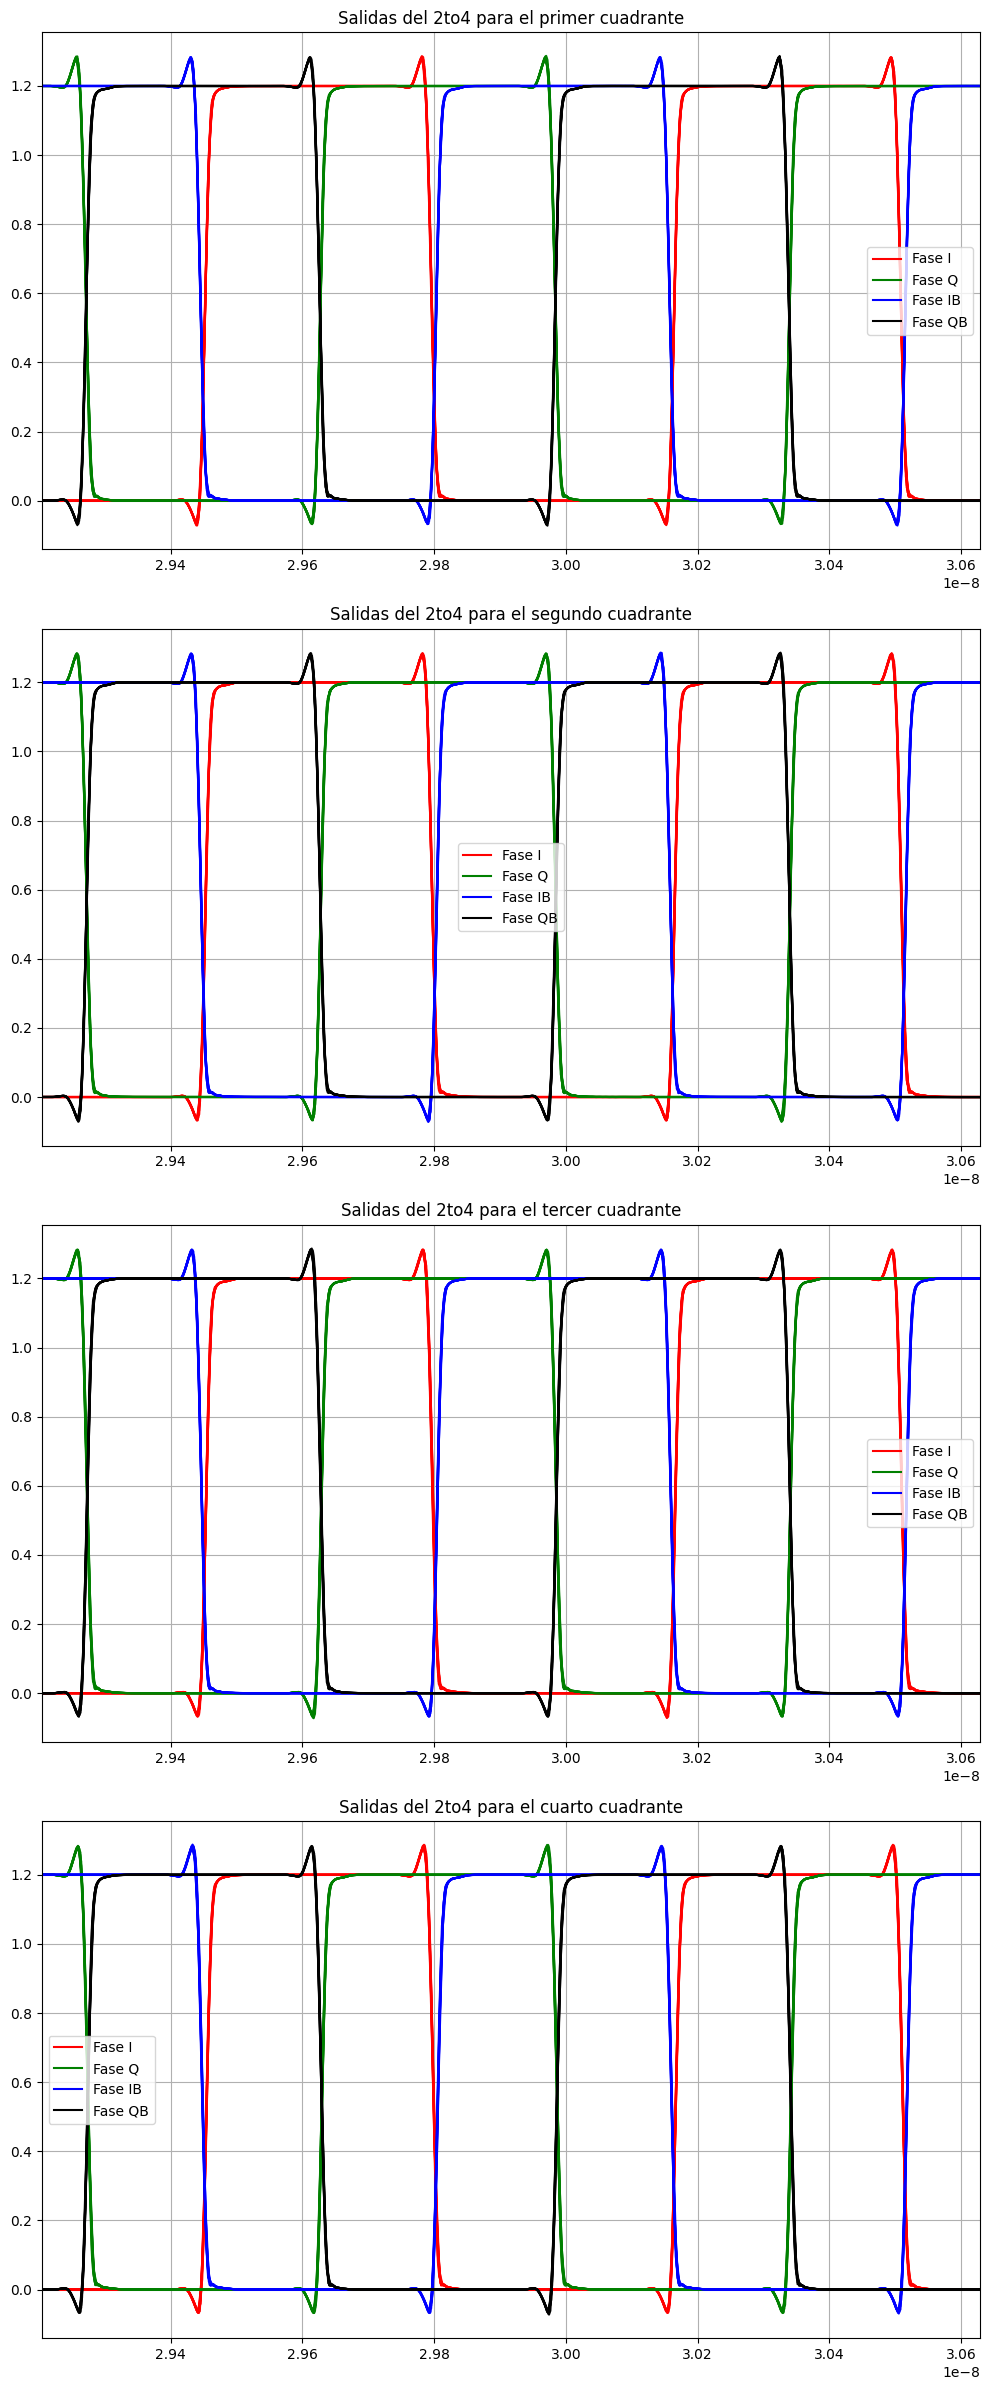

In [347]:
# Generación de ventana de gráficos
results8i = plt.figure(figsize=[10,24])
quadrant18i = results8i.add_subplot(4,1,1)
quadrant28i = results8i.add_subplot(4,1,2)
quadrant38i = results8i.add_subplot(4,1,3)
quadrant48i = results8i.add_subplot(4,1,4)

# Primer cuadrante
clks_QUADRv2(v2to4i_Q1,time_Q1,1,stable_period,'I','r',quadrant18i)
clks_QUADRv2(v2to4q_Q1,time_Q1,1,stable_period,'Q','g',quadrant18i)
clks_QUADRv2(v2to4ib_Q1,time_Q1,1,stable_period,'IB','b',quadrant18i)
clks_QUADRv2(v2to4qb_Q1,time_Q1,1,stable_period,'QB','k',quadrant18i)
quadrant18i.set_xlim(OFFS+stable_period, OFFS+stable_period*3)
quadrant18i.set_title('Salidas del 2to4 para el primer cuadrante')

# Segundo cuadrante
clks_QUADRv2(v2to4i_Q2,time_Q2,2,stable_period,'I','r',quadrant28i)
clks_QUADRv2(v2to4q_Q2,time_Q2,2,stable_period,'Q','g',quadrant28i)
clks_QUADRv2(v2to4ib_Q2,time_Q2,2,stable_period,'IB','b',quadrant28i)
clks_QUADRv2(v2to4qb_Q2,time_Q2,2,stable_period,'QB','k',quadrant28i)
quadrant28i.set_xlim(OFFS+stable_period, OFFS+stable_period*3)
quadrant28i.set_title('Salidas del 2to4 para el segundo cuadrante')

# Tercer cuadrante
clks_QUADRv2(v2to4i_Q3,time_Q3,3,stable_period,'I','r',quadrant38i)
clks_QUADRv2(v2to4q_Q3,time_Q3,3,stable_period,'Q','g',quadrant38i)
clks_QUADRv2(v2to4ib_Q3,time_Q3,3,stable_period,'IB','b',quadrant38i)
clks_QUADRv2(v2to4qb_Q3,time_Q3,3,stable_period,'QB','k',quadrant38i)
quadrant38i.set_xlim(OFFS+stable_period, OFFS+stable_period*3)
quadrant38i.set_title('Salidas del 2to4 para el tercer cuadrante')

# Cuarto cuadrante
clks_QUADRv2(v2to4i_Q4,time_Q4,4,stable_period,'I','r',quadrant48i)
clks_QUADRv2(v2to4q_Q4,time_Q4,4,stable_period,'Q','g',quadrant48i)
clks_QUADRv2(v2to4ib_Q4,time_Q4,4,stable_period,'IB','b',quadrant48i)
clks_QUADRv2(v2to4qb_Q4,time_Q4,4,stable_period,'QB','k',quadrant48i)
quadrant48i.set_xlim(OFFS+stable_period, OFFS+stable_period*3)
quadrant48i.set_title('Salidas del 2to4 para el cuarto cuadrante')

results8i.tight_layout()

### Análisis de las señales de control del 8xPI

Para analizar si las señales de control del 8xPI se comportan como deberían, voy a graficar los códigos termométricos de entrada (no negado) y de salida (a veces negado) y las señales de los cuadrantes.            

El objetivo es ver cómo se comportan las señales de control que ingresan directamente al bloque principal 8xPI (núcleo del PI digamos). Como ya se tiene una tabla de verdad de cómo responde el PI a diferentes entradas, se puede saber si los circuitos de control están funcionando correctamente o no.           

Las señales externas de control (las que se generan con fuentes tipo PULSE) hacen un contador ascendente de módulo 5 con MSB en v4 y LSB en v0 (ver esquemático). En teoría, para esas entradas externas, los circuitos de control deberían adaptar las señales de control para generar un sweep de fase lineal en sentido antihorario.

Como los códigos termométricos tienen 7 salidas, y no es claro graficar las 7 salidas, voy a hacer una señal que sea la suma de todas las 7 salidas así se ve el efecto termómetro en los plots.

In [348]:
### Suma de las 7 salidas TermoIn (No negado)
termo_in = [0]*len(resultados['time'])
for i in range(len(resultados['time'])):
    termo_in[i] = np.round(t_in1[i]+t_in2[i]+t_in3[i]+t_in4[i]+t_in5[i]+t_in6[i]+t_in7[i],decimals=1)

### Suma de las 7 salidas TermoOut (Negado a veces)
termo_out = [0]*len(resultados['time'])
for i in range(len(resultados['time'])):
    termo_out[i] = np.round(t_out1[i]+t_out2[i]+t_out3[i]+t_out4[i]+t_out5[i]+t_out6[i]+t_out7[i],decimals=1)


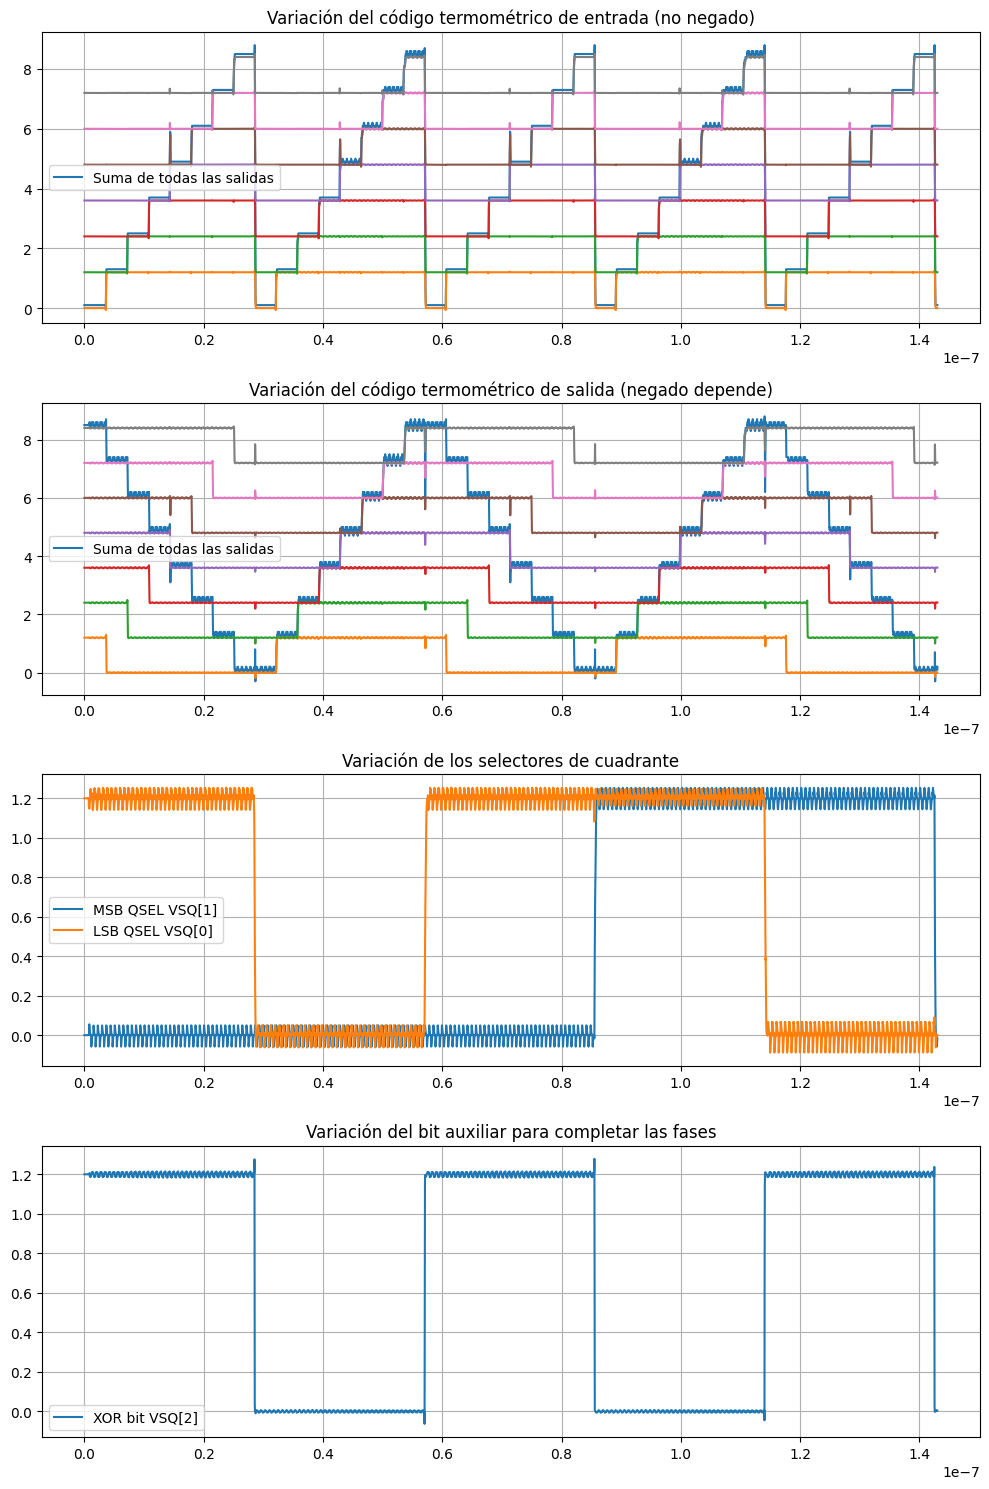

In [349]:
### Generacion de plots con las senales de control
fig_control = plt.figure(figsize=[10,15])
ax_termo_in = fig_control.add_subplot(4,1,1)
ax_termo_out = fig_control.add_subplot(4,1,2)
ax_qsel = fig_control.add_subplot(4,1,3)
ax_xor_bit = fig_control.add_subplot(4,1,4)

# Termoin
ax_termo_in.plot(resultados['time'], [x+0.1 for x in termo_in], label='Suma de todas las salidas')
ax_termo_in.plot(resultados['time'], t_in7)
ax_termo_in.plot(resultados['time'], [x+1.2*1 for x in t_in6])
ax_termo_in.plot(resultados['time'], [x+1.2*2 for x in t_in5])
ax_termo_in.plot(resultados['time'], [x+1.2*3 for x in t_in4])
ax_termo_in.plot(resultados['time'], [x+1.2*4 for x in t_in3])
ax_termo_in.plot(resultados['time'], [x+1.2*5 for x in t_in2])
ax_termo_in.plot(resultados['time'], [x+1.2*6 for x in t_in1])
ax_termo_in.set_title('Variación del código termométrico de entrada (no negado)')
ax_termo_in.grid()
ax_termo_in.legend()

# Termoout
ax_termo_out.plot(resultados['time'], [x+0.1 for x in termo_out], label='Suma de todas las salidas')
ax_termo_out.plot(resultados['time'], t_out7)
ax_termo_out.plot(resultados['time'], [x+1.2*1 for x in t_out6])
ax_termo_out.plot(resultados['time'], [x+1.2*2 for x in t_out5])
ax_termo_out.plot(resultados['time'], [x+1.2*3 for x in t_out4])
ax_termo_out.plot(resultados['time'], [x+1.2*4 for x in t_out3])
ax_termo_out.plot(resultados['time'], [x+1.2*5 for x in t_out2])
ax_termo_out.plot(resultados['time'], [x+1.2*6 for x in t_out1])
ax_termo_out.set_title('Variación del código termométrico de salida (negado depende)')
ax_termo_out.grid()
ax_termo_out.legend()

# Selectores de cuadrante
ax_qsel.plot(resultados['time'], qsel_MSB, label='MSB QSEL VSQ[1]')
ax_qsel.plot(resultados['time'], qsel_LSB, label='LSB QSEL VSQ[0]')
ax_qsel.set_title('Variación de los selectores de cuadrante')
ax_qsel.grid()
ax_qsel.legend()

# Bit XOR para completar las fases
ax_xor_bit.plot(resultados['time'],xor_bit, label='XOR bit VSQ[2]')
ax_xor_bit.set_title('Variación del bit auxiliar para completar las fases')
ax_xor_bit.grid()
ax_xor_bit.legend()

fig_control.tight_layout()


## Medición del desfase de cada salida

El objetivo de hacer esta simulación, además de graficar de una manera específica los resultados, es obtener mediciones precisas del desfase que hay en las salidas del clock. Para poder calcular esto, se va a utilizar una nueva función que registre el tiempo en el que ocurren los flancos ascendentes dentro de un cuadrante de la simulación.       

Esta función va a tener como entrada la salida de simulación y el tiempo en ese cuadrante, y va a tener como salida una lista de valores que corresponden al desfase medido.   

El desfase se va a medir con respecto a la salida del 8xPI generada con la instancia que mantiene la fase 8I en todo momento.

In [350]:
def phase_measv2(quadr_out: list[float],
                 quadr_8i: list[float],
                 quadr_time: list[float],
                 stable_period: float,
                 threshold: float,
                 quadr: int
                 ) -> list[float]:

    ph_out = []


    for i in np.arange(0,8):
        start_samp = np.abs(quadr_time - (i)*stable_period*5 - (quadr)*stable_period*40 - stable_period*2).argmin()
        time8I_samp = start_samp
        if (quadr_8i[time8I_samp] >= threshold):
            while (quadr_8i[time8I_samp] >= threshold):
                time8I_samp = time8I_samp+1
    
        while(quadr_8i[time8I_samp] < threshold):
            time8I_samp = time8I_samp+1
        time8I = quadr_time[time8I_samp]

        time_ph_samp = time8I_samp
        if (quadr_out[time_ph_samp] >= threshold):
            while (quadr_out[time_ph_samp] >= threshold):
                time_ph_samp = time_ph_samp+1
        
        while (quadr_out[time_ph_samp] < threshold):
            time_ph_samp = time_ph_samp+1
            
        time_ph = quadr_time[time_ph_samp]
        diff_ph = round((time_ph - time8I)*360/stable_period - 12.635915, ndigits=5)
        if diff_ph >= 360: 
            diff_ph -= 360
        elif diff_ph < 0:
            diff_ph += 360
        
        ph_out.append(diff_ph)   
    
    return ph_out
            

In [351]:
phase_Q1 = phase_measv2(vout_Q1,v8i_Q1,time_Q1,stable_period,0.6,1)
print(phase_Q1)
phase_Q2 = phase_measv2(vout_Q2,v8i_Q2,time_Q2,stable_period,0.6,2)
print(phase_Q2)
phase_Q3 = phase_measv2(vout_Q3,v8i_Q3,time_Q3,stable_period,0.6,3)
print(phase_Q3)
phase_Q4 = phase_measv2(vout_Q4,v8i_Q4,time_Q4,stable_period,0.6,4)
print(phase_Q4)

[np.float64(0.0), np.float64(10.10873), np.float64(27.79902), np.float64(48.01648), np.float64(63.17958), np.float64(75.8155), np.float64(85.92423), np.float64(90.9786)]
[np.float64(93.50578), np.float64(106.1417), np.float64(121.3048), np.float64(136.4679), np.float64(151.631), np.float64(161.73973), np.float64(171.84846), np.float64(174.37565)]
[np.float64(179.43001), np.float64(192.06593), np.float64(209.75621), np.float64(226.43562), np.float64(242.60959), np.float64(255.24551), np.float64(260.29988), np.float64(269.14502)]
[np.float64(272.93579), np.float64(285.57171), np.float64(298.20762), np.float64(315.89791), np.float64(331.06101), np.float64(343.69692), np.float64(349.89127), np.float64(357.47282)]


In [352]:
phase_sweep = list(dict.fromkeys(phase_Q1+phase_Q2+phase_Q3+phase_Q4))
print(len(phase_sweep))

32


### Medición (o cálculo) de la INL y la DNL

La DNL y la INL son especificaciones que hablan de la linealidad de conversión de una entrada digital de bits (entradas de control del PI) a una salida analógica de fase (salida del PI). Para calcular cada una voy a hacer una función en la que ingrese el sweep de fase y egrese una lista con los valores de la INL y DNL para cada entrada de control.              

Para poner un contexto, la INL (Integral NonLinearity) es la diferencia que hay entre cada valor de fase con respecto al valor ideal lineal que se busca que haya en un conversor. Esta se puede expresar en grados (porque sería una diferencia de fases al fin y al cabo) o en LSB (Less Significant Bit), normalizando la cantidad anterior en grados al mínimo cambio que se puede efectuar en las entradas del conversor.

Por otro lado, la DNL (Differencial NonLinearity) se define como la diferencia que existe entre el salto de fase de la salida al siguiente valor con respecto al salto ideal.          

Es claro entonces, que para calcular ambas, primero hay que definir cuál sería la característica de transferencia ideal. Esto es sencillo, si el rango en la salida es de 360° y hay 32 valores posibles de fase, cada valor tendría que ser 11.25° mayor que el anterior para hacer una excursión completamente lineal. En la siguiente celda se genera y grafica la característica de transferencia ideal con respecto a la real.

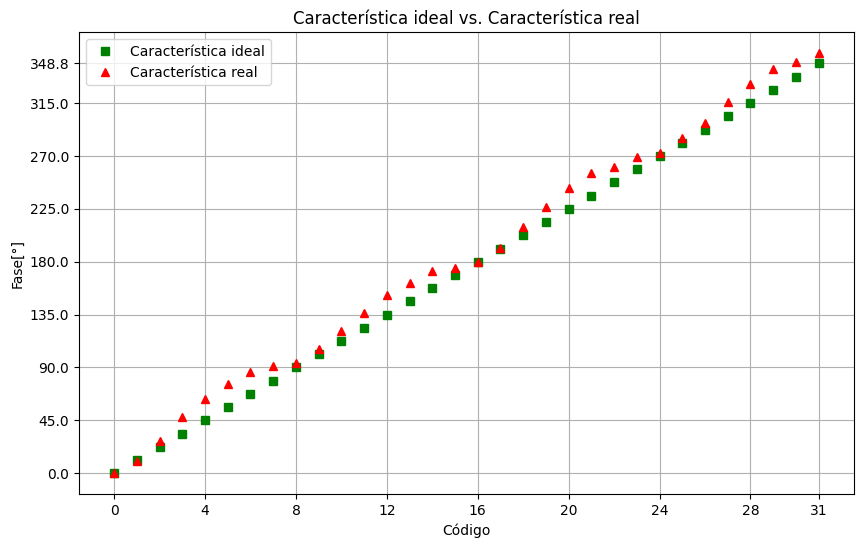

In [353]:
phase_sweep_ideal = np.linspace(0,360,32, endpoint=False)
codigo = np.arange(0,32)

fig_ideal_sweep, ax_ideal_sweep = plt.subplots(figsize=[10,6])
#ax_ideal_sweep.plot(codigo,phase_sweep_ideal,'g')
ax_ideal_sweep.plot(codigo,phase_sweep_ideal,'gs',label='Característica ideal')
ax_ideal_sweep.plot(codigo,phase_sweep,'r^', label='Característica real')
ax_ideal_sweep.set_xlabel('Código')
ax_ideal_sweep.set_ylabel('Fase[°]')
ax_ideal_sweep.set_title('Característica ideal vs. Característica real')
ax_ideal_sweep.set_xticks([0,4,8,12,16,20,24,28,31])
ax_ideal_sweep.set_yticks([0,45,90,135,180,225,270,315,348.75])
ax_ideal_sweep.grid()
ax_ideal_sweep.legend()


In [354]:
def calc_INL(ideal: list[float], real: list[float]) -> list[float]:
    
    INL = [0]*len(ideal)
    step = 360/len(ideal)
    for i in range(0,len(ideal)):
        INL[i] = (real[i] - ideal[i])/step
    
    return INL

In [355]:
def calc_DNL(real: list[float]) -> list[float]:
    
    DNL = [0]*(len(real)-1)
    step = 360/len(real)
    for i in range(0,len(real)-1):
        DNL[i] = (real[i+1] - real[i] - step)/step
    
    return DNL

In [356]:
def calc_SKEW(sig_out: list[float],
              sig_time: list[float],
              stable_period: float,
              threshold: float
              ) -> list[float]:
    

    skew = []
    start_samp = np.abs(sig_time - stable_period*2 -stable_period*40).argmin()
    if (sig_out[start_samp] >= threshold):
        while (sig_out[start_samp] >= threshold):
            start_samp = start_samp+1
    
    while(sig_out[start_samp] < threshold):
        start_samp = start_samp+1
    time_posedge = sig_time[start_samp]

    for i in np.arange(1,32):
        new_start_samp = np.abs(sig_time - time_posedge- stable_period*5).argmin()
        while (sig_out[new_start_samp] < threshold):
            new_start_samp = new_start_samp+1
            
        nx_ph_time_posedge = sig_time[new_start_samp]
        diff_time_posedge = np.round((nx_ph_time_posedge - time_posedge - stable_period*5)*1e12, decimals=4)   # en ps
        
        skew.append(diff_time_posedge)   

        time_posedge = nx_ph_time_posedge

    return skew

In [357]:
INL = calc_INL(phase_sweep_ideal,phase_sweep)
print(INL)
DNL = calc_DNL(phase_sweep)
print(DNL)
SKEW = calc_SKEW(np.array(resultados['v(vout)'][offs_time:],dtype=float),np.array(resultados['time'][offs_time:],dtype=float),stable_period,0.6)
print(SKEW)

[np.float64(0.0), np.float64(-0.10144622222222226), np.float64(0.4710239999999999), np.float64(1.2681315555555557), np.float64(1.6159626666666669), np.float64(1.7391555555555556), np.float64(1.6377093333333328), np.float64(1.0869866666666668), np.float64(0.311624888888889), np.float64(0.4348177777777778), np.float64(0.782648888888889), np.float64(1.1304799999999988), np.float64(1.4783111111111111), np.float64(1.3768648888888897), np.float64(1.2754186666666656), np.float64(0.5000577777777784), np.float64(-0.05066577777777689), np.float64(0.07252711111111189), np.float64(0.6449964444444454), np.float64(1.1276106666666668), np.float64(1.5652968888888887), np.float64(1.6884897777777774), np.float64(1.1377671111111087), np.float64(0.9240017777777767), np.float64(0.26095911111111086), np.float64(0.38415199999999966), np.float64(0.5073440000000018), np.float64(1.0798142222222245), np.float64(1.4276453333333343), np.float64(1.5508373333333314), np.float64(1.101446222222224), np.float64(0.77536

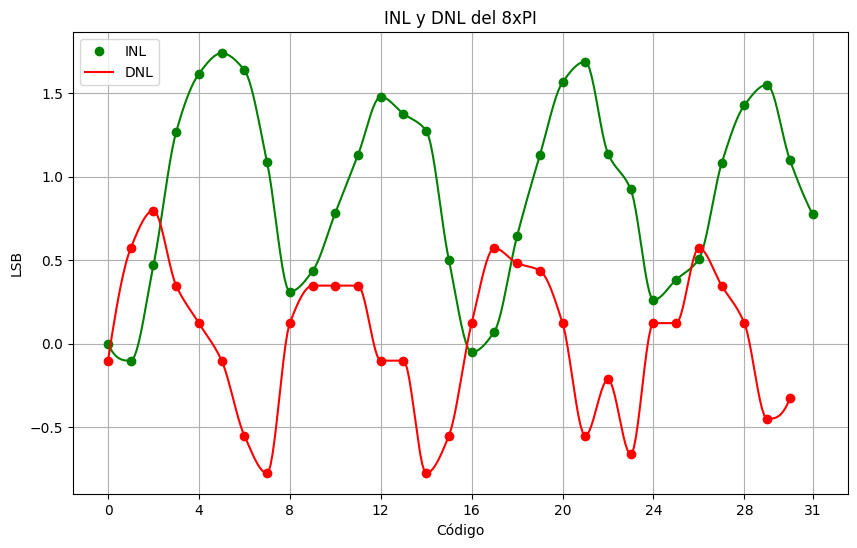

In [358]:
from scipy.interpolate import PchipInterpolator

INL_inter = PchipInterpolator(codigo,INL)
DNL_inter = PchipInterpolator(codigo[:-1],DNL)
fine_codigo_INL = np.linspace(codigo.min(),codigo.max(),10*len(codigo))
fine_codigo_DNL = np.linspace(codigo[0],codigo.max()-1,10*len(codigo))

fig_INL_DNL, ax_DNL_INL = plt.subplots(figsize=[10,6])
#ax_DNL_INL.plot(codigo,INL,'g')
ax_DNL_INL.plot(fine_codigo_INL,INL_inter(fine_codigo_INL),'g')
ax_DNL_INL.plot(codigo,INL,'go',label='INL')
ax_DNL_INL.plot(fine_codigo_DNL,DNL_inter(fine_codigo_DNL),'r', label='DNL')
ax_DNL_INL.plot(codigo[:-1],DNL,'ro')
ax_DNL_INL.set_xlabel('Código')
ax_DNL_INL.set_ylabel('LSB')
ax_DNL_INL.set_title('INL y DNL del 8xPI')
ax_DNL_INL.set_xticks([0,4,8,12,16,20,24,28,31])
#ax_DNL_INL.set_yticks([0,45,90,135,180,225,270,315,348.75])
ax_DNL_INL.grid()
ax_DNL_INL.legend()


### Medición del ancho de pulso en cada fase

Para medir el ancho de pulso de cada fase voy a utilizar una función similar a la que mide la fase (o el desfase) de la salida, porque al fin y al cabo tengo que detectar las transiciones de subida y bajada de los pulsos. En teoría, el valor ideal sería 250 ps porque el periodo del clock sería 500 ps (frecuencia 2 MHz). La función va a medir el ancho del pulso positivo.

In [359]:
def PW_measv3(quadr_out: list[float],
            quadr_time: list[float],
            stable_period: float,
            threshold: float,
            quadr: int
            ) -> list[float]:

    PW_out = []

    for i in np.arange(0,8):
        samp_pw_start = np.abs(quadr_time - (i)*stable_period*5 - (quadr)*stable_period*40 - stable_period).argmin()
        
        if (quadr_out[samp_pw_start] >= threshold):
            while (quadr_out[samp_pw_start] >= threshold):
                samp_pw_start = samp_pw_start+1

        while(quadr_out[samp_pw_start] < threshold):
            samp_pw_start = samp_pw_start+1
        
        samp_pw_end = samp_pw_start
        while (quadr_out[samp_pw_end] >= threshold):
            samp_pw_end = samp_pw_end+1
            
        time_pw_start = quadr_time[samp_pw_start]
        time_pw_end = quadr_time[samp_pw_end]
        diff_time = round((time_pw_end - time_pw_start)*1e12, ndigits=5)

        PW_out.append(diff_time)
            
    
    return PW_out

In [360]:
pw_Q1 = PW_measv3(vout_Q1,time_Q1,stable_period,0.6,1)
print(pw_Q1)
pw_Q2 = PW_measv3(vout_Q2,time_Q2,stable_period,0.6,2)
print(pw_Q2)
pw_Q3 = PW_measv3(vout_Q3,time_Q3,stable_period,0.6,3)
print(pw_Q3)
pw_Q4 = PW_measv3(vout_Q4,time_Q4,stable_period,0.6,4)
print(pw_Q4)

### Concatenacion de todas las mediciones
pw = pw_Q1+pw_Q2+pw_Q3+pw_Q4

[365.0, 370.0, 370.0, 370.0, 365.0, 355.0, 355.0, 350.0]
[350.0, 355.0, 369.0, 370.0, 370.0, 365.0, 365.0, 360.0]
[360.0, 365.0, 375.0, 370.0, 368.0, 365.0, 360.0, 360.0]
[360.0, 365.0, 372.5, 375.0, 370.0, 370.0, 367.5, 365.0]


### Tablas de interés

Voy a generar una tabla que diga plotee la información numérica de un solo vistazo

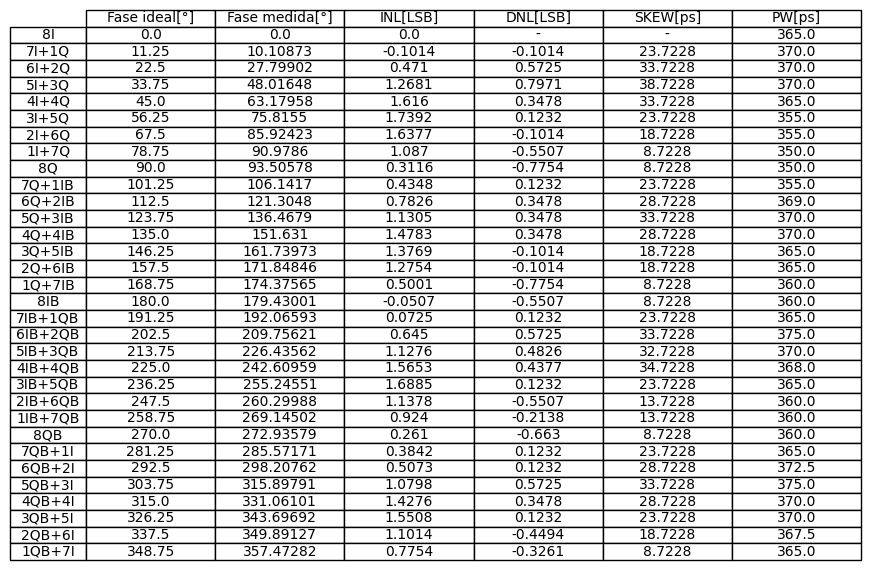

In [361]:
columnas = ['Fase ideal[°]', 'Fase medida[°]', 'INL[LSB]','DNL[LSB]','SKEW[ps]','PW[ps]']

filas = []
for i in range(0,4):
    match i:
        case 0:
            for n in range(0,8):
                if(n == 0):
                    filas.append('8I')
                else:
                    filas.append(f'{8-n}I+{n}Q')
        case 1:
            for n in range(0,8):
                if(n == 0):
                    filas.append('8Q')
                else:
                    filas.append(f'{8-n}Q+{n}IB')
        case 2:
            for n in range(0,8):
                if(n == 0):
                    filas.append('8IB')
                else:
                    filas.append(f'{8-n}IB+{n}QB')
        case 3:
            for n in range(0,8):
                if(n == 0):
                    filas.append('8QB')
                else:
                    filas.append(f'{8-n}QB+{n}I')

data = list(zip(phase_sweep_ideal,phase_sweep,np.round(INL,decimals=4),['-']+list(np.round(DNL,decimals=4)),['-']+SKEW,pw))

fig_table , ax_table = plt.subplots(figsize=[10,6])
ax_table.axis('off')

ax_table.table(data,colLabels=columnas,rowLabels=filas, loc='center', cellLoc='center', rowLoc='center')



### Evolución transitoria de la fase a lo largo de toda la simulación

Para medir los glitches transistorios de fase que puede haber en cada transición, sería de gran utilidad contar con un sweep de fase completamente lineal, no uno artificial como el que se generó hasta ahora. No obstante, voy a escribir una función que mida en todos los ciclos de clock la fase de la señal de salida (de fase variable) con respecto a la salida 8I de la instancia que mantiene la fase constante.          

Aunque ya se hizo una gráfica de la linealidad de la fase, la idea con esta otra gráfica es observar si hay efectos transitorios en la fase de salida o (glitches). La estructura de la función en general va a ser muy similar a la función ``phase_meas()``, pero va a tener la diferencia de que la medición va a ser en todos los ciclos de simulación y con ciclos consecutivos. 

In [362]:
def phase_tran_meas(quadr_out: list[float],
                    quadr_8i: list[float],
                    quadr_time: list[float],
                    threshold: float,
                    stable_period: float
                    ) -> list[float]:

    ph_out = []
    cycles = np.round((np.max(quadr_time)-min(quadr_time))/stable_period)

    for i in np.arange(0,cycles-1):
        start_samp = np.abs(quadr_time - i*stable_period - stable_period*40).argmin()
        time8I_samp = start_samp
        if (quadr_8i[time8I_samp] >= threshold):
            while (quadr_8i[time8I_samp] >= threshold):
                time8I_samp = time8I_samp+1

        while(quadr_8i[time8I_samp] < threshold):
            time8I_samp = time8I_samp+1
        time8I = quadr_time[time8I_samp]

        time_ph_samp = time8I_samp
        if (quadr_out[time_ph_samp] > threshold):
            while (quadr_out[time_ph_samp] >= threshold):
                time_ph_samp = time_ph_samp+1
        
        while (quadr_out[time_ph_samp] < threshold):
            time_ph_samp = time_ph_samp+1
        time_ph = quadr_time[time_ph_samp]

        diff_ph = np.round((time_ph - time8I)*360/stable_period - 12.635915,decimals=7)
        if diff_ph >= 360: 
            diff_ph -= 360
        elif diff_ph < 0:
            diff_ph += 360
        
        ph_out.append(diff_ph)
    
    return ph_out

/tmp/ipykernel_314363/3137329829.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_phase_tran.legend()


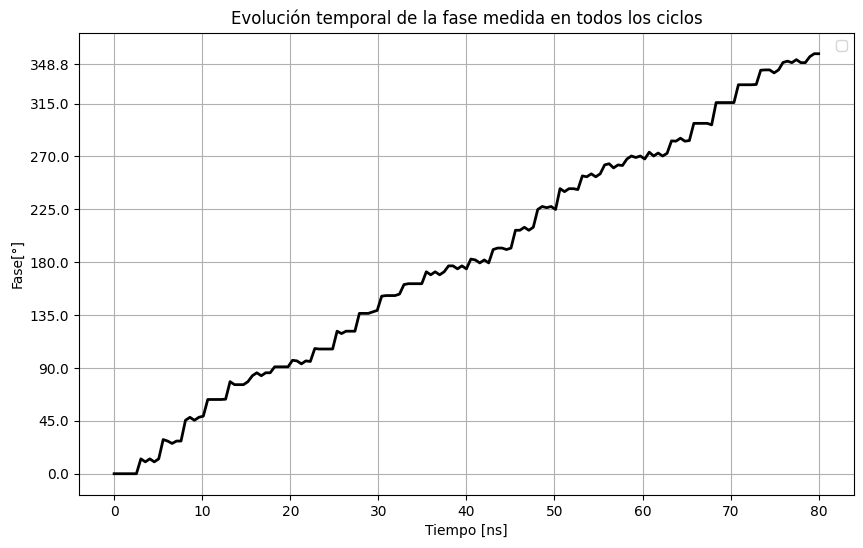

In [363]:
phase_tran = phase_tran_meas(resultados['v(vout)'][offs_time+100:],resultados['v(vout8i)'][offs_time+100:],resultados['time'][offs_time+100:],0.6,stable_period)
tiempo = np.linspace(0,80,len(phase_tran))


fig_phase_tran, ax_phase_tran = plt.subplots(figsize=[10,6])
#ax_phase_tran.plot(codigo,phase_sweep_ideal,'g')
ax_phase_tran.plot(tiempo,phase_tran,'k',linewidth=2)
#ax_phase_tran.plot(codigo,phase_sweep,'r^', label='Característica real')
ax_phase_tran.set_xlabel('Tiempo [ns]')
ax_phase_tran.set_ylabel('Fase[°]')
ax_phase_tran.set_title('Evolución temporal de la fase medida en todos los ciclos')
#ax_phase_tran.set_xticks([0,4,8,12,16,20,24,28,31])
ax_phase_tran.set_yticks([0,45,90,135,180,225,270,315,348.75])
ax_phase_tran.grid()
ax_phase_tran.legend()